Belgacem Smaali / Wassim Ghrab

## Déclaration d'usage d'IA

Les algorithmes utilisés proviennent de notre librairie iads, développée pendant les TME, et la démarche expérimentale comme l'analyse des résultats sont les nôtres. Conformément à l'énoncé, on précise avoir utilisé l'assistant Claude Code sur certaines parties : il nous a aidés à écrire les fonctions les plus techniques à partir de nos spécifications, notamment l'ACP et la validation croisée stratifiée, ainsi qu'à corriger quelques bugs. On est en mesure d'expliquer l'ensemble du code rendu.

In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes) :
import scipy

# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2
# --------------------------------


In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [3]:
# chargement Fashion MNIST
data_train = pd.read_csv('../data/fashion-mnist_train.csv')
data_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data_test = pd.read_csv('../data/fashion-mnist_test.csv')
data_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [5]:
data_train.shape

(60000, 785)

In [6]:
data_test.shape

(10000, 785)

## Apprentissage supervisé : classification binaire

On compare trois familles de classifieurs (k plus proches voisins, perceptron, arbre de
décision numérique) sur deux paires de classes, l'une facile et l'autre difficile, et selon
trois représentations des images (brute, normalisée, ACP).

Protocole : sélection d'un sous-échantillon équilibré du train (graine fixée), étude des
hyper-paramètres par validation croisée stratifiée (5 plis) sur le train, puis évaluation du
meilleur réglage de chaque famille sur le test.

Pour éviter toute fuite de données, le prétraitement (normalisation min-max, ACP) est appris
**à l'intérieur de chaque pli**, sur les seules données d'apprentissage du pli, puis appliqué au
pli de test ; de même, pour le test final, il est appris sur le train seul et appliqué au test.
Aucune donnée de test ne participe donc à l'apprentissage du prétraitement.

Conventions rappelées : labels en -1/+1 ; `predict` agit sur un exemple (on utilise
`predict_all` pour un lot).

In [ ]:
# Outils pour les experiences binaires
from IPython.display import display

# noms des classes Fashion MNIST
noms_classes = ['T-shirt','Pantalon','Pull','Robe','Manteau',
                'Sandale','Chemise','Basket','Sac','Bottine']

def extrait_paire(dtrain, dtest, c0, c1):
    # garde les 2 classes et remappe les labels : c0 -> -1, c1 -> +1

    def prep(df):
        sub = df[(df['label']==c0) | (df['label']==c1)]
        X = sub.drop(columns='label').values.astype(float)
        y = np.where(sub['label'].values==c1, 1, -1)
        return X, y
    Xtr, ytr = prep(dtrain)
    Xte, yte = prep(dtest)

    return Xtr, ytr, Xte, yte

def sous_echantillon(X, y, n_par_classe, seed=42):
    # sous-ensemble equilibre, graine fixée pour la reproductibilite

    rng = np.random.default_rng(seed)
    idx = []

    for c in np.unique(y):
        ic = np.where(y==c)[0]
        idx += list(rng.choice(ic, min(n_par_classe, len(ic)), replace=False))

    idx = np.array(idx)
    rng.shuffle(idx)

    return X[idx], y[idx]

# Pretraitements : appris sur Xapp (train du pli), appliqués au train et au test du pli
def pretrait_brut(Xapp, Xtest):
    # pixels ramenés dans [0,1] : rien a apprendre

    return Xapp/255.0, Xtest/255.0

def pretrait_normalise(Xapp, Xtest):
    # min-max appris sur le train du pli (meme logique que clust.normalisation)
    
    Xa, Xt = Xapp/255.0, Xtest/255.0
    mn = Xa.min(axis=0)
    ec = Xa.max(axis=0) - mn
    ec[ec==0] = 1   # colonne constante -> pas de division par zero

    return (Xa - mn)/ec, (Xt - mn)/ec

def fait_pretrait_acp(k):
    # renvoie un pretraitement ACP a k composantes

    def pretrait(Xapp, Xtest):
        Xa, infos = ut.acp(Xapp/255.0, k)               # ACP apprise sur le train du pli
        return Xa, ut.applique_acp(Xtest/255.0, infos)  # meme transfo pour le test
    
    return pretrait

def etude_hyperparam(constructeur, valeurs, X, y, pretraitement, nb_plis=5):
    # CV stratifiee sans fuite pour chaque valeur d'hyper-parametre

    lignes = []

    for v in valeurs:
        t = time.time()
        perfs, moy, ec = ev.validation_croisee_strat_pretrait(constructeur(v), (X, y), nb_plis, pretraitement)
        lignes.append({'param':v, 'acc_moy':round(moy,4), 'acc_std':round(ec,4),
                       'folds':np.round(perfs,3).tolist(), 'temps_s':round(time.time()-t,2)})
        
    return pd.DataFrame(lignes)

def montre_images(dtrain, c0, c1, n=6):
    # affiche n images de chaque classe, une classe par ligne

    fig, axes = plt.subplots(2, n, figsize=(1.4*n, 3))

    for ligne, c in enumerate([c0, c1]):
        imgs = dtrain[dtrain['label']==c].drop(columns='label').values[:n]
        for j in range(n):
            axes[ligne, j].imshow(imgs[j].reshape(28,28), cmap='gray')
            axes[ligne, j].set_xticks([]); axes[ligne, j].set_yticks([])
        axes[ligne, 0].set_ylabel(noms_classes[c], size=12)
        
    plt.tight_layout(); plt.show()

### Les deux paires étudiées

- Paire facile : Pantalon (1) contre Sac (8), deux silhouettes très différentes.
- Paire difficile : Pull (2) contre Manteau (4), deux hauts proches en forme.

Paire FACILE : Pantalon vs Sac


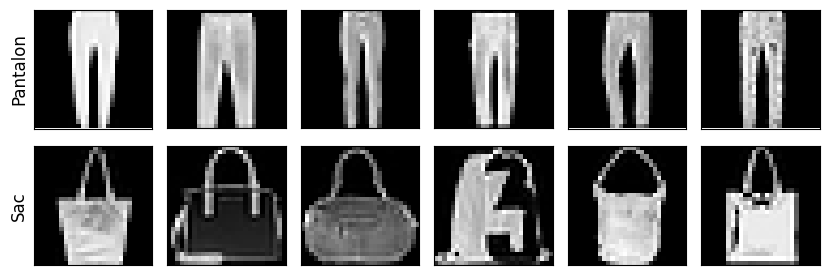

Paire DIFFICILE : Pull vs Manteau


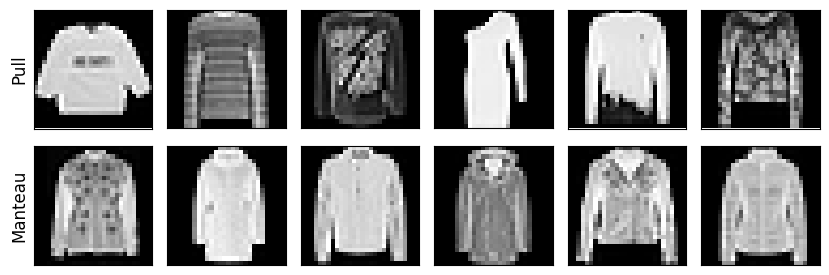

In [8]:
print("Paire FACILE :", noms_classes[1], "vs", noms_classes[8])
montre_images(data_train, 1, 8)
print("Paire DIFFICILE :", noms_classes[2], "vs", noms_classes[4])
montre_images(data_train, 2, 4)

### Choix et limites

Nos implémentations sont écrites « à la main ». Le kNN et le perceptron restent rapides,
mais l'arbre numérique devient coûteux en grande dimension (il teste chaque seuil de chaque
attribut à chaque nœud). D'où nos choix :

- sous-échantillon principal de 1000 exemples par classe (kNN, perceptron, et arbre sur ACP) ;
- l'arbre sur les pixels bruts (784 dimensions) est seulement mesuré à titre indicatif, sur un
  échantillon réduit (300 par classe, 3 plis), car une étude complète y serait trop longue ;
- pour un arbre, la normalisation min-max ne change rien : étant monotone colonne par colonne,
  elle donne exactement les mêmes coupures que sur le brut (vérifié). On ne la recalcule pas.

In [ ]:
# Etude complete d'une paire, en validation croisée
def construit(famille, d, param):
    # param vient d'une colonne pandas mixte : on caste selon la famille (k entier, lr/eps reels)

    if famille=='kNN':        return cl.ClassifierKNN(d, int(param))
    if famille=='Perceptron': return cl.ClassifierPerceptron(d, learning_rate=float(param))
    if famille=='Arbre':      return cl.ClassifierArbreNumerique(d, float(param))

def etudie_paire(nom, c0, c1, n_par_classe=1000, n_arbre_brut=300):

    np.random.seed(42)   # reproductibilité : le perceptron mélange les exemples aléatoirement

    print("="*70)
    print(f"PAIRE {nom} : {noms_classes[c0]} ({c0}) vs {noms_classes[c1]} ({c1})")
    print("="*70)
    Xtr, ytr, Xte, yte = extrait_paire(data_train, data_test, c0, c1)
    Xs, ys = sous_echantillon(Xtr, ytr, n_par_classe)     # pixels bruts (0-255), non transformés
    print(f"train complet {Xtr.shape} | sous-echantillon {Xs.shape} ({n_par_classe}/classe) | test {Xte.shape}")
    _, infos = ut.acp(Xs/255.0, 50)   # pour information seulement
    print(f"ACP 50 composantes (info) : variance expliquee cumulee = {infos['variance_cumulee'][-1]:.3f}")

    d = Xs.shape[1]
    repres = {'brut':(pretrait_brut, d), 'normalise':(pretrait_normalise, d), 'acp':(fait_pretrait_acp(50), 50)}

    resume = []   # une ligne par (famille, representation) avec le meilleur hyper-parametre

    # kNN : etude de k sur les 3 representations
    print("\n--- kNN : etude de k (CV 5 plis, sans fuite) ---")

    for r in ['brut','normalise','acp']:
        pre, dd = repres[r]
        tab = etude_hyperparam(lambda k: cl.ClassifierKNN(dd,k), [1,3,5,7,9], Xs, ys, pre)
        tab.insert(0,'representation',r); display(tab)
        b = tab.loc[tab['acc_moy'].idxmax()]
        resume.append({'classifieur':'kNN','representation':r,'param':int(b['param']),
                       'acc_cv':b['acc_moy'],'temps_s':b['temps_s']})

    # Perceptron : etude du learning rate
    print("\n--- Perceptron (avec biais) : etude du learning_rate (CV 5 plis, sans fuite) ---")

    for r in ['brut','normalise','acp']:
        pre, dd = repres[r]
        tab = etude_hyperparam(lambda lr: cl.ClassifierPerceptron(dd,learning_rate=lr), [0.001,0.01,0.1], Xs, ys, pre)
        tab.insert(0,'representation',r); display(tab)
        b = tab.loc[tab['acc_moy'].idxmax()]
        resume.append({'classifieur':'Perceptron','representation':r,'param':float(b['param']),
                       'acc_cv':b['acc_moy'],'temps_s':b['temps_s']})

    # Arbre : etude d'epsilon sur ACP (praticable)
    print("\n--- Arbre numerique : etude d'epsilon sur ACP50 (CV 5 plis, sans fuite) ---")
    pre, dd = repres['acp']
    tab = etude_hyperparam(lambda e: cl.ClassifierArbreNumerique(dd,e), [0.0,0.1,0.2], Xs, ys, pre)
    tab.insert(0,'representation','acp'); display(tab)
    ba = tab.loc[tab['acc_moy'].idxmax()]
    resume.append({'classifieur':'Arbre','representation':'acp','param':float(ba['param']),
                   'acc_cv':ba['acc_moy'],'temps_s':ba['temps_s']})

    # Arbre sur brut 784D : indicatif (echantillon reduit, CV 3 plis)
    print(f"\n--- Arbre numerique sur brut 784D : indicatif ({n_arbre_brut}/classe, CV 3 plis, eps=0.1) ---")
    Xrb, yrb = sous_echantillon(Xtr, ytr, n_arbre_brut, seed=3)
    tabb = etude_hyperparam(lambda e: cl.ClassifierArbreNumerique(784,e), [0.1], Xrb, yrb, pretrait_brut, nb_plis=3)
    tabb.insert(0,'representation','brut*'); display(tabb)
    resume.append({'classifieur':'Arbre','representation':'brut*','param':0.1,
                   'acc_cv':round(tabb['acc_moy'][0],4),'temps_s':tabb['temps_s'][0]})

    resume = pd.DataFrame(resume)
    print("\n>>> Synthese (validation croisee sans fuite) de la paire :")
    display(resume[['classifieur','representation','param','acc_cv','temps_s']])

    # config = meilleur reglage de chaque famille
    config = {}
    for fam in ['kNN','Perceptron']:
        sous = resume[resume['classifieur']==fam]
        row = sous.loc[sous['acc_cv'].idxmax()]
        config[fam] = {'rep':row['representation'], 'param':row['param']}
    config['Arbre'] = {'rep':'acp', 'param':float(ba['param'])}   # arbre : etude faite sur l'ACP

    return {'nom':nom,'c0':c0,'c1':c1,'Xs':Xs,'ys':ys,'Xte':Xte,'yte':yte,'repres':repres,'config':config}

def evalue_test(res):
    # reentraine le meilleur reglage de chaque famille (pretrait appris sur le train complet) et l'evalue sur le test

    np.random.seed(42)   # reproductibilite

    print("="*70); print(f"TEST FINAL : {res['nom']}"); print("="*70)
    Xs, ys, Xte, yte, repres = res['Xs'], res['ys'], res['Xte'], res['yte'], res['repres']
    lignes = []

    for fam, cfg in res['config'].items():
        pre, d = repres[cfg['rep']]
        Xs_t, Xte_t = pre(Xs, Xte)   # transfo apprise sur le train complet, appliquee au test
        clf = construit(fam, d, cfg['param'])
        t = time.time(); clf.train(Xs_t, ys); tt = time.time()-t
        pred = ev.predict_all(clf, Xte_t)
        lignes.append({'famille':fam,'representation':cfg['rep'],'param':cfg['param'],
                       'acc_test':round(float((pred==yte).mean()),4),'temps_train_s':round(tt,2)})
        
    tab = pd.DataFrame(lignes); display(tab)
    # matrice de confusion du meilleur reglage
    best = tab.loc[tab['acc_test'].idxmax()]; fam = best['famille']; cfg = res['config'][fam]
    pre, d = repres[cfg['rep']]; Xs_t, Xte_t = pre(Xs, Xte)
    clf = construit(fam, d, cfg['param']); clf.train(Xs_t, ys); pred = ev.predict_all(clf, Xte_t)
    M = ev.matrice_confusion((yte+1)//2, (pred+1)//2, 2)

    print(f"Meilleur sur le test : {fam} ({cfg['rep']}) -> matrice de confusion")
    ev.affiche_matrice_confusion(M, [noms_classes[res['c0']], noms_classes[res['c1']]])

    return tab

### Étude de la paire facile (Pantalon vs Sac)

In [10]:
res_facile = etudie_paire('FACILE', 1, 8)

PAIRE FACILE : Pantalon (1) vs Sac (8)


train complet (12000, 784) | sous-echantillon (2000, 784) (1000/classe) | test (2000, 784)
ACP 50 composantes (info) : variance expliquee cumulee = 0.889

--- kNN : etude de k (CV 5 plis, sans fuite) ---


,representation,param,acc_moy,acc_std,folds,temps_s
0,brut,1,0.9925,0.0045,"[0.998, 0.985, 0.995, 0.995, 0.99]",2.41
1,brut,3,0.9935,0.0034,"[0.998, 0.988, 0.995, 0.992, 0.995]",2.39
2,brut,5,0.9910,0.0037,"[0.998, 0.988, 0.99, 0.988, 0.992]",2.37
3,brut,7,0.9925,0.0047,"[1.0, 0.985, 0.992, 0.992, 0.992]",2.37
4,brut,9,0.9925,0.0050,"[1.0, 0.985, 0.995, 0.99, 0.992]",2.35


,representation,param,acc_moy,acc_std,folds,temps_s
0,normalise,1,0.9925,0.0045,"[0.998, 0.985, 0.995, 0.995, 0.99]",2.37
1,normalise,3,0.9930,0.0043,"[0.998, 0.985, 0.995, 0.992, 0.995]",2.37
2,normalise,5,0.9910,0.0037,"[0.998, 0.988, 0.99, 0.988, 0.992]",2.37
3,normalise,7,0.9930,0.0048,"[1.0, 0.985, 0.995, 0.992, 0.992]",2.36
4,normalise,9,0.9925,0.0050,"[1.0, 0.985, 0.995, 0.99, 0.992]",2.36


,representation,param,acc_moy,acc_std,folds,temps_s
0,acp,1,0.9910,0.0054,"[0.998, 0.982, 0.992, 0.995, 0.988]",0.62
1,acp,3,0.9950,0.0022,"[0.998, 0.992, 0.998, 0.992, 0.995]",0.62
2,acp,5,0.9925,0.0032,"[0.998, 0.988, 0.992, 0.992, 0.992]",0.62
3,acp,7,0.9915,0.0034,"[0.998, 0.988, 0.992, 0.99, 0.99]",0.63
4,acp,9,0.9905,0.0048,"[0.998, 0.982, 0.992, 0.99, 0.99]",0.62


...

,representation,param,acc_moy,acc_std,folds,temps_s
0,acp,0.0,0.9870,0.0073,"[0.99, 0.972, 0.99, 0.99, 0.992]",32.66
1,acp,0.1,0.9865,0.0051,"[0.988, 0.978, 0.99, 0.992, 0.985]",20.93
2,acp,0.2,0.9810,0.0064,"[0.988, 0.978, 0.97, 0.985, 0.985]",16.85



--- Arbre numerique sur brut 784D : indicatif (300/classe, CV 3 plis, eps=0.1) ---


,representation,param,acc_moy,acc_std,folds,temps_s
0,brut*,0.1,0.9733,0.0024,"[0.975, 0.975, 0.97]",10.69



>>> Synthese (validation croisee sans fuite) de la paire :


,classifieur,representation,param,acc_cv,temps_s
0,kNN,brut,3.000,0.9935,2.39
1,kNN,normalise,3.000,0.9930,2.37
2,kNN,acp,3.000,0.9950,0.62
3,Perceptron,brut,0.001,0.9945,0.13
4,Perceptron,normalise,0.010,0.9960,0.17
5,Perceptron,acp,0.100,0.9970,0.45
6,Arbre,acp,0.000,0.9870,32.66
7,Arbre,brut*,0.100,0.9733,10.69


### Étude de la paire difficile (Pull vs Manteau)

In [11]:
res_difficile = etudie_paire('DIFFICILE', 2, 4)

PAIRE DIFFICILE : Pull (2) vs Manteau (4)


train complet (12000, 784) | sous-echantillon (2000, 784) (1000/classe) | test (2000, 784)
ACP 50 composantes (info) : variance expliquee cumulee = 0.894

--- kNN : etude de k (CV 5 plis, sans fuite) ---


,representation,param,acc_moy,acc_std,folds,temps_s
0,brut,1,0.8080,0.0191,"[0.792, 0.782, 0.815, 0.838, 0.812]",2.36
1,brut,3,0.8150,0.0063,"[0.808, 0.82, 0.822, 0.818, 0.808]",2.35
2,brut,5,0.8245,0.0149,"[0.802, 0.815, 0.835, 0.825, 0.845]",2.38
3,brut,7,0.8285,0.0117,"[0.822, 0.818, 0.845, 0.818, 0.84]",2.35
4,brut,9,0.8295,0.0151,"[0.82, 0.808, 0.848, 0.828, 0.845]",2.35


,representation,param,acc_moy,acc_std,folds,temps_s
0,normalise,1,0.8090,0.0173,"[0.798, 0.782, 0.815, 0.832, 0.818]",2.35
1,normalise,3,0.8145,0.0040,"[0.808, 0.818, 0.818, 0.818, 0.812]",2.35
2,normalise,5,0.8235,0.0133,"[0.802, 0.818, 0.83, 0.825, 0.842]",2.35
3,normalise,7,0.8290,0.0134,"[0.822, 0.818, 0.848, 0.815, 0.842]",2.35
4,normalise,9,0.8300,0.0129,"[0.822, 0.812, 0.845, 0.825, 0.845]",2.35


,representation,param,acc_moy,acc_std,folds,temps_s
0,acp,1,0.8040,0.0115,"[0.795, 0.788, 0.81, 0.82, 0.808]",0.62
1,acp,3,0.8085,0.0068,"[0.805, 0.802, 0.82, 0.812, 0.802]",0.62
2,acp,5,0.8265,0.0090,"[0.815, 0.825, 0.842, 0.828, 0.822]",0.62
3,acp,7,0.8300,0.0063,"[0.825, 0.82, 0.835, 0.835, 0.835]",0.62
4,acp,9,0.8260,0.0096,"[0.82, 0.81, 0.835, 0.832, 0.832]",0.62


...

,representation,param,acc_moy,acc_std,folds,temps_s
0,acp,0.0,0.7430,0.0170,"[0.732, 0.775, 0.745, 0.735, 0.728]",66.12
1,acp,0.1,0.7425,0.0170,"[0.732, 0.775, 0.742, 0.735, 0.728]",65.45
2,acp,0.2,0.7460,0.0142,"[0.745, 0.772, 0.745, 0.735, 0.732]",63.87



--- Arbre numerique sur brut 784D : indicatif (300/classe, CV 3 plis, eps=0.1) ---


,representation,param,acc_moy,acc_std,folds,temps_s
0,brut*,0.1,0.7467,0.0437,"[0.7, 0.735, 0.805]",34.81



>>> Synthese (validation croisee sans fuite) de la paire :


,classifieur,representation,param,acc_cv,temps_s
0,kNN,brut,9.000,0.8295,2.35
1,kNN,normalise,9.000,0.8300,2.35
2,kNN,acp,7.000,0.8300,0.62
3,Perceptron,brut,0.010,0.8380,2.16
4,Perceptron,normalise,0.001,0.8125,2.17
5,Perceptron,acp,0.010,0.7930,2.07
6,Arbre,acp,0.200,0.7460,63.87
7,Arbre,brut*,0.100,0.7467,34.81


### Synthèse binaire et évaluation sur le test

Pour chaque famille, on retient la représentation et l'hyper-paramètre de meilleure accuracy
en validation croisée, puis on évalue ce réglage sur le test complet de la paire.

TEST FINAL : FACILE


,famille,representation,param,acc_test,temps_train_s
0,kNN,acp,3.0,0.996,0.00
1,Perceptron,acp,0.1,0.995,0.04
2,Arbre,acp,0.0,0.993,9.78


Meilleur sur le test : kNN (acp) -> matrice de confusion


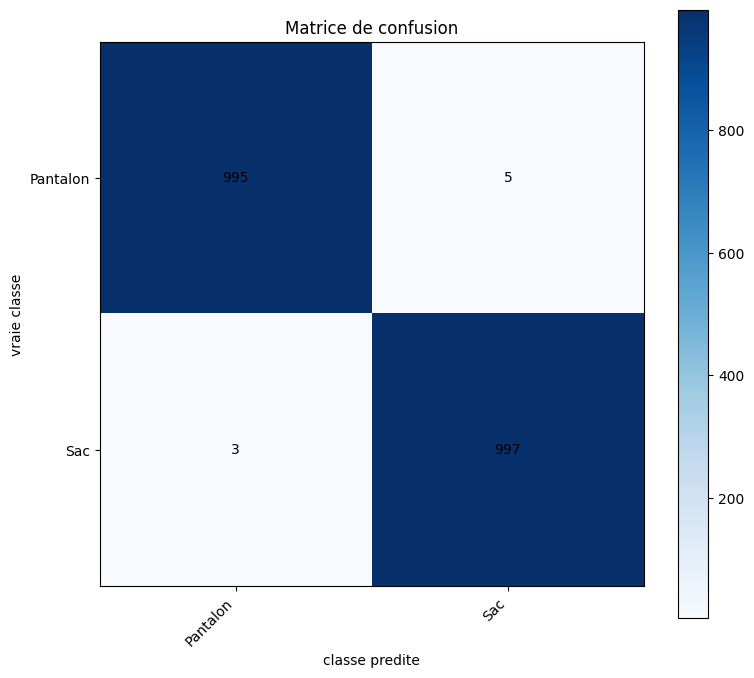

TEST FINAL : DIFFICILE


,famille,representation,param,acc_test,temps_train_s
0,kNN,normalise,9.00,0.8470,0.00
1,Perceptron,brut,0.01,0.8320,0.57
2,Arbre,acp,0.20,0.7745,16.71


Meilleur sur le test : kNN (normalise) -> matrice de confusion


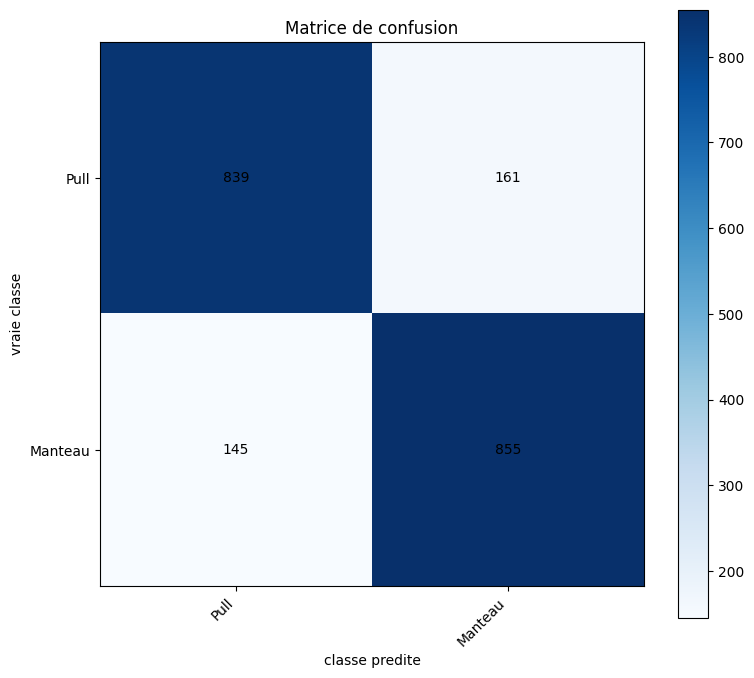

In [12]:
tab_test_facile = evalue_test(res_facile)
tab_test_difficile = evalue_test(res_difficile)

### Bilan du volet binaire

Tous les chiffres ci-dessous sont obtenus en validation croisée stratifiée sans fuite : le
prétraitement (normalisation, ACP) est appris dans chaque pli sur le train du pli seul. Une
graine fixée rend l'étude reproductible. (On avait d'abord appris le prétraitement sur tout
le train : les conclusions sont identiques, la fuite étant mineure car l'ACP est non supervisée.)

Quelle famille gagne ? Le kNN sur les deux paires (0.996 sur la facile, 0.847 sur la difficile).
Le perceptron est juste derrière sur la facile (0.996), mais décroche sur la difficile (0.840) :
une seule droite sépare bien deux formes très différentes, pas deux hauts qui se ressemblent. L'arbre numérique est
systématiquement le plus faible (0.993 et 0.775).

Écart facile / difficile. Pantalon vs Sac est presque parfait : 8 erreurs sur 2000. Pull vs
Manteau plafonne autour de 85 % : la matrice de confusion du kNN montre 161 pulls pris pour des
manteaux et 145 manteaux pris pour des pulls. Les deux classes se ressemblent beaucoup, comme on le voyait déjà sur les images.

Effet de la représentation.
- L'ACP (50 composantes, environ 89 % de variance) conserve l'accuracy du kNN tout en étant
  environ 4 fois plus rapide (0.6 s contre 2.4 s par validation croisée). Sur nos implémentations
  « à la main », c'est un gain net, et l'ACP rend aussi l'arbre praticable.
- La normalisation min-max change peu le kNN (les pixels sont déjà à la même échelle) mais c'est
  elle qui donne le meilleur kNN au test sur la paire difficile (0.847).
- L'ACP ne profite pas au perceptron sur la paire difficile (0.81 contre 0.84 en brut) : tronquer
  à 50 axes réduit légèrement la séparabilité linéaire.
- Pour l'arbre, brut et normalisé donnent exactement le même résultat (coupures par seuil,
  normalisation monotone), et l'ACP donne un arbre plus rapide que sur les 784 pixels.

Coût. L'arbre numérique « from scratch » passe mal à l'échelle en grande dimension (d'où
l'échantillon réduit sur le brut), alors que le kNN et le perceptron restent rapides.

## Apprentissage supervisé : classification multi-classe (10 classes)

On passe aux dix classes de Fashion MNIST. On réutilise la validation croisée stratifiée
sans fuite (le prétraitement est appris dans chaque pli) et la stratégie un-contre-tous
(`ClassifierMultiOAA`) pour rendre les classifieurs binaires multi-classes.

Préparation du sous-échantillon équilibré et vérification de l'équilibre des classes.

sous-echantillon train : (5000, 784)  (500/classe)
test complet           : (10000, 784)


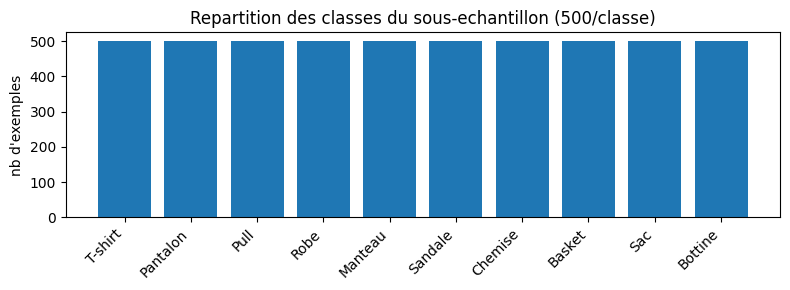

effectifs par classe : [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


In [ ]:
# preparation du multi-classe
# sous-echantillon equilibré des 10 classes, graine fixée. On vise 500/classe au depart
N_PAR_CLASSE = 500

def prepare_multi(dtrain, dtest, n_par_classe=N_PAR_CLASSE, seed=42):

    Xtr = dtrain.drop(columns='label').values.astype(float); ytr = dtrain['label'].values
    Xte = dtest.drop(columns='label').values.astype(float);  yte = dtest['label'].values
    rng = np.random.default_rng(seed)
    idx = []

    for c in range(10):
        ic = np.where(ytr==c)[0]
        idx += list(rng.choice(ic, n_par_classe, replace=False))
    idx = np.array(idx); rng.shuffle(idx)

    return Xtr[idx], ytr[idx], Xte, yte

Xm, ym, Xte_m, yte_m = prepare_multi(data_train, data_test)
print(f"sous-echantillon train : {Xm.shape}  ({N_PAR_CLASSE}/classe)")
print(f"test complet           : {Xte_m.shape}")

# On reutilise les memes preprocesseurs sans fuite que le binaire :
# pretrait_brut, pretrait_normalise, fait_pretrait_acp(k) -> appris dans chaque pli.
# Ici les labels sont 0..9 (pas -1/+1) : ClassifierMultiOAA gere n'importe quelles classes.

# Verification de l'equilibre des classes du sous-echantillon
effectifs = np.bincount(ym, minlength=10)

plt.figure(figsize=(8,3))
plt.bar([noms_classes[c] for c in range(10)], effectifs)
plt.xticks(rotation=45, ha='right'); plt.ylabel("nb d'exemples")
plt.title(f"Repartition des classes du sous-echantillon ({N_PAR_CLASSE}/classe)")
plt.tight_layout(); plt.show()
print("effectifs par classe :", effectifs.tolist())

### Comparaison des classifieurs (10 classes)

On compare trois classifieurs en validation croisée stratifiée sans fuite :
- `ClassifierMultiOAA(ClassifierPerceptron)` sur ACP et sur normalisé (pour voir si l'ACP le gêne
  comme en binaire) ;
- `ClassifierMultiOAA(ClassifierKNN)` avec k=9 (bon réglage du binaire) sur ACP ;
- `ClassifierArbreNumerique` sur ACP.

Note sur le coût : l'arbre numérique « à la main » est très lent en multi-classe (un seul arbre
sur l'échantillon prend plus de deux minutes). On l'évalue donc en 3 plis et avec un seul
epsilon, alors que le kNN et le perceptron sont évalués en 5 plis. Les temps sont reportés.

In [ ]:
# etude des 3 classifieurs en CV stratifiée 
pre_acp = fait_pretrait_acp(50)

resultats_multi = []   # une ligne par modele

def evalue_cv(nom, C, pretraitement, nb_plis):
    
    t = time.time()
    perfs, moy, ec = ev.validation_croisee_strat_pretrait(C, (Xm, ym), nb_plis, pretraitement)
    dt = time.time() - t
    resultats_multi.append({'modele':nom, 'acc_moy':round(moy,4), 'acc_std':round(ec,4),
                            'plis':nb_plis, 'temps_s':round(dt,1)})
    print(f"{nom:32s} acc={moy:.4f} +/- {ec:.4f}  ({nb_plis} plis, {dt:.1f}s)")

print("--- perceptron multi-classe (OAA) ---")
evalue_cv("OAA(perceptron) ACP",       cl.ClassifierMultiOAA(cl.ClassifierPerceptron(50, learning_rate=0.01)), pre_acp,            5)
evalue_cv("OAA(perceptron) normalise", cl.ClassifierMultiOAA(cl.ClassifierPerceptron(784, learning_rate=0.01)), pretrait_normalise, 5)

print("--- kNN multi-classe (OAA, k=9) ---")
evalue_cv("OAA(kNN k=9) ACP",          cl.ClassifierMultiOAA(cl.ClassifierKNN(50, 9)), pre_acp, 5)

print("--- arbre numerique (3 plis, plus lent) ---")
evalue_cv("Arbre numerique ACP",       cl.ClassifierArbreNumerique(50, 0.0), pre_acp, 3)

tab_multi = pd.DataFrame(resultats_multi)
print("\n>>> Synthese multi-classe (CV stratifiee sans fuite) :")
display(tab_multi)

--- perceptron multi-classe (OAA) ---


OAA(perceptron) ACP              acc=0.7768 +/- 0.0325  (5 plis, 40.5s)


OAA(perceptron) normalise        acc=0.7926 +/- 0.0218  (5 plis, 38.9s)
--- kNN multi-classe (OAA, k=9) ---


OAA(kNN k=9) ACP                 acc=0.8142 +/- 0.0137  (5 plis, 19.5s)
--- arbre numerique (3 plis, plus lent) ---


Arbre numerique ACP              acc=0.6976 +/- 0.0133  (3 plis, 267.1s)

>>> Synthese multi-classe (CV stratifiee sans fuite) :


,modele,acc_moy,acc_std,plis,temps_s
0,OAA(perceptron) ACP,0.7768,0.0325,5,40.5
1,OAA(perceptron) normalise,0.7926,0.0218,5,38.9
2,OAA(kNN k=9) ACP,0.8142,0.0137,5,19.5
3,Arbre numerique ACP,0.6976,0.0133,3,267.1


### Évaluation du meilleur modèle sur le test complet

On reprend le meilleur modèle en validation croisée, on l'entraîne sur tout le sous-échantillon
(prétraitement appris sur le train, appliqué au test) et l'évaluons sur les 10000 images de test.

Meilleur modele en CV : OAA(kNN k=9) ACP (acc=0.8142)


Accuracy sur le test complet (10000 images) : 0.8210


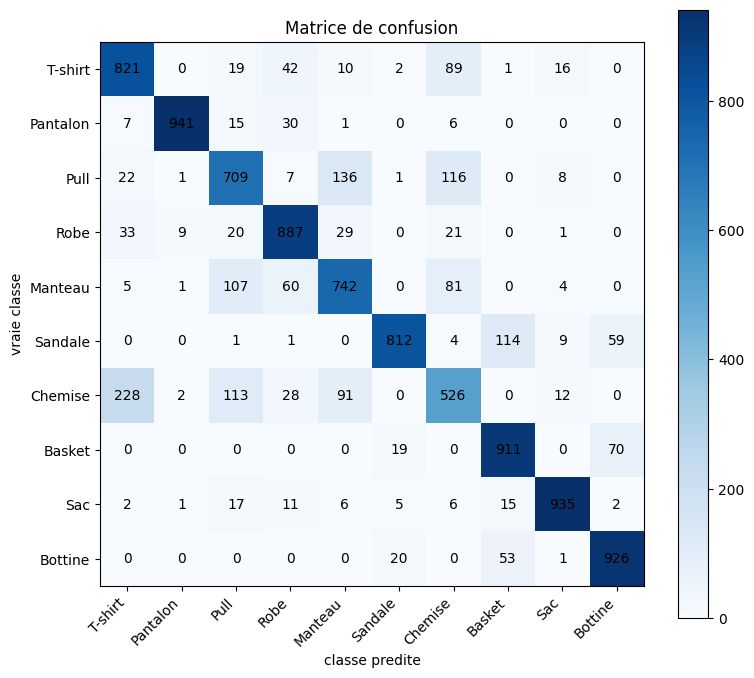

Precision / rappel par classe :


,classe,precision,rappel
0,T-shirt,0.734,0.821
1,Pantalon,0.985,0.941
2,Pull,0.708,0.709
3,Robe,0.832,0.887
4,Manteau,0.731,0.742
5,Sandale,0.945,0.812
6,Chemise,0.620,0.526
7,Basket,0.833,0.911
8,Sac,0.948,0.935
9,Bottine,0.876,0.926


In [ ]:
# Réentrainement du meilleur modele et evaluation sur le test complet
best = tab_multi.loc[tab_multi['acc_moy'].idxmax()]
print("Meilleur modele en CV :", best['modele'], f"(acc={best['acc_moy']})")

# on reconstruit ce modele et sa representation (ACP pour tous nos meilleurs candidats)
if 'kNN' in best['modele']:
    modele_final = cl.ClassifierMultiOAA(cl.ClassifierKNN(50, 9))

elif 'perceptron' in best['modele']:
    rep_acp = 'ACP' in best['modele']
    d = 50 if rep_acp else 784
    modele_final = cl.ClassifierMultiOAA(cl.ClassifierPerceptron(d, learning_rate=0.01))

else:
    modele_final = cl.ClassifierArbreNumerique(50, 0.0)

pre = pre_acp if 'ACP' in best['modele'] else pretrait_normalise
Xtr_t, Xte_t = pre(Xm, Xte_m)               # transfo apprise sur le train, appliquee au test
modele_final.train(Xtr_t, ym)
pred_test = ev.predict_all(modele_final, Xte_t)
acc_test = (pred_test == yte_m).mean()

print(f"Accuracy sur le test complet ({len(yte_m)} images) : {acc_test:.4f}")

# Matrice de confusion 10x10
M = ev.matrice_confusion(yte_m, pred_test, 10)
ev.affiche_matrice_confusion(M, noms_classes)

# Precision / rappel par classe
acc_glob, precisions, rappels = ev.metriques_par_classe(M)
tab_pr = pd.DataFrame({'classe':noms_classes,
                       'precision':np.round(precisions,3),
                       'rappel':np.round(rappels,3)})
print("Precision / rappel par classe :")
display(tab_pr)

### Analyse des confusions

On regarde les paires de classes les plus confondues (hors diagonale) et on affiche
quelques images mal classées pour les relier au visuel.

Paires de classes les plus confondues (total des deux sens) :
  T-shirt  <-> Chemise  : 317  (T-shirt->Chemise=89, Chemise->T-shirt=228)
  Pull     <-> Manteau  : 243  (Pull->Manteau=136, Manteau->Pull=107)
  Pull     <-> Chemise  : 229  (Pull->Chemise=116, Chemise->Pull=113)
  Manteau  <-> Chemise  : 172  (Manteau->Chemise=81, Chemise->Manteau=91)
  Sandale  <-> Basket   : 133  (Sandale->Basket=114, Basket->Sandale=19)

Classes les plus faciles (rappel eleve) : ['Pantalon 0.94', 'Sac 0.94', 'Bottine 0.93']
Classes les plus difficiles (rappel faible) : ['Chemise 0.53', 'Pull 0.71', 'Manteau 0.74']


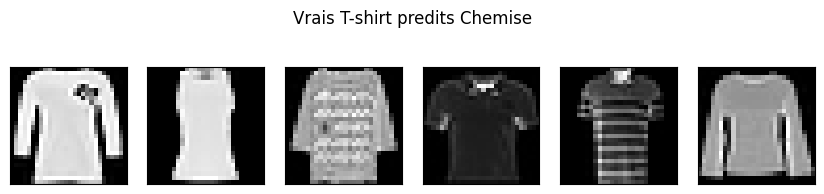

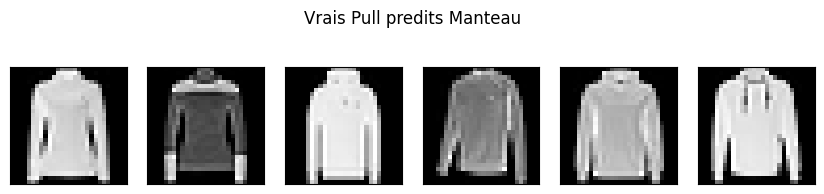

In [ ]:
# Paires les plus confondues (somme des deux sens, hors diagonale)
paires = []

for i in range(10):
    for j in range(i+1, 10):
        paires.append((M[i,j] + M[j,i], i, j))
paires.sort(reverse=True)

print("Paires de classes les plus confondues (total des deux sens) :")

for total, i, j in paires[:5]:
    print(f"  {noms_classes[i]:8s} <-> {noms_classes[j]:8s} : {total}  ({noms_classes[i]}->{noms_classes[j]}={M[i,j]}, {noms_classes[j]}->{noms_classes[i]}={M[j,i]})")

# Classes les plus faciles / difficiles (rappel)
ordre = np.argsort(rappels)

print("\nClasses les plus faciles (rappel eleve) :", [f"{noms_classes[c]} {rappels[c]:.2f}" for c in ordre[::-1][:3]])
print("Classes les plus difficiles (rappel faible) :", [f"{noms_classes[c]} {rappels[c]:.2f}" for c in ordre[:3]])

# Images mal classees pour les 2 paires les plus confondues
for total, i, j in paires[:2]:
    # exemples de vraie classe i predits en classe j
    mask = (yte_m==i) & (pred_test==j)
    imgs = Xte_m[mask][:6]
    if len(imgs)==0: continue
    fig, axes = plt.subplots(1, len(imgs), figsize=(1.4*len(imgs), 1.8))
    if len(imgs)==1: axes=[axes]

    for ax, im in zip(axes, imgs):
        ax.imshow(im.reshape(28,28), cmap='gray'); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Vrais {noms_classes[i]} predits {noms_classes[j]}", y=1.05)

    plt.tight_layout(); plt.show()

## Apprentissage non-supervisé : clustering par k-moyennes

Question directrice : en supervisé, les « hauts » (T-shirt, Pull, Manteau, Chemise) se confondent
fortement. Sans utiliser les labels, est-ce que le clustering regroupe lui aussi ces classes ?
Si c'est le cas, c'est que la confusion vient des données, pas de nos algorithmes.

On travaille sur la représentation ACP (50 composantes) du sous-échantillon des dix classes
(500/classe), comme en supervisé. En non-supervisé il n'y a pas de découpage train/test, donc pas
de risque de fuite : l'ACP est apprise sur tout le sous-échantillon.

Choix du nombre de clusters k (méthode du coude et indices de Dunn et Xie-Beni).

In [ ]:
# préparation des donnees pour le clustering
# On reprend le sous-echantillon multi-classe (Xm en pixels 0-255) et on le projette en ACP 50.
Xm_acp, _ = ut.acp(Xm/255.0, 50)
df_acp = pd.DataFrame(Xm_acp)    

print("donnees pour le clustering :", df_acp.shape)

donnees pour le clustering : (5000, 50)


In [ ]:
# k-means : pour chaque k, on relance plusieurs fois (init aleatoire) et on garde la partition
# de plus faible inertie, puis on calcule les indices de qualite.

def meilleur_kmeans(df, k, n_init=5, iter_max=20, epsilon=0.01):

    meilleur = None

    for graine in range(n_init):
        np.random.seed(graine)          # reproductibilite
        km = clust.KMoyennes(k)
        Centres, U = km.train(df, epsilon, iter_max)
        inertie = km.inertie_globale(df, U)
        
        if meilleur is None or inertie < meilleur['inertie']:
            meilleur = {'inertie':inertie, 'Centres':Centres, 'U':U}

    return meilleur

liste_k = [5, 8, 10, 12, 15]
res_kmeans = []
partitions = {}                          # on garde les partitions pour l'analyse d'apres

for k in liste_k:
    m = meilleur_kmeans(df_acp, k)
    dunn = clust.index_Dunn(df_acp, m['Centres'], m['U'])
    xb = clust.index_XieBeni(df_acp, m['Centres'], m['U'])
    res_kmeans.append({'k':k, 'inertie':round(m['inertie'],1), 'Dunn':round(dunn,4), 'Xie-Beni':round(xb,4)})
    partitions[k] = m

    print(f"k={k:2d} : inertie={m['inertie']:9.1f}  Dunn={dunn:.4f}  Xie-Beni={xb:.4f}")

tab_kmeans = pd.DataFrame(res_kmeans)

print("\n>>> Tableau k -> inertie / Dunn / Xie-Beni :")

display(tab_kmeans)

k= 5 : inertie= 149896.3  Dunn=0.3439  Xie-Beni=0.7935


k= 8 : inertie= 123248.9  Dunn=0.3005  Xie-Beni=0.9063


k=10 : inertie= 113194.6  Dunn=0.2962  Xie-Beni=1.0525


k=12 : inertie= 105424.5  Dunn=0.3057  Xie-Beni=0.9199


k=15 : inertie=  95670.7  Dunn=0.2872  Xie-Beni=0.9463

>>> Tableau k -> inertie / Dunn / Xie-Beni :


,k,inertie,Dunn,Xie-Beni
0,5,149896.3,0.3439,0.7935
1,8,123248.9,0.3005,0.9063
2,10,113194.6,0.2962,1.0525
3,12,105424.5,0.3057,0.9199
4,15,95670.7,0.2872,0.9463


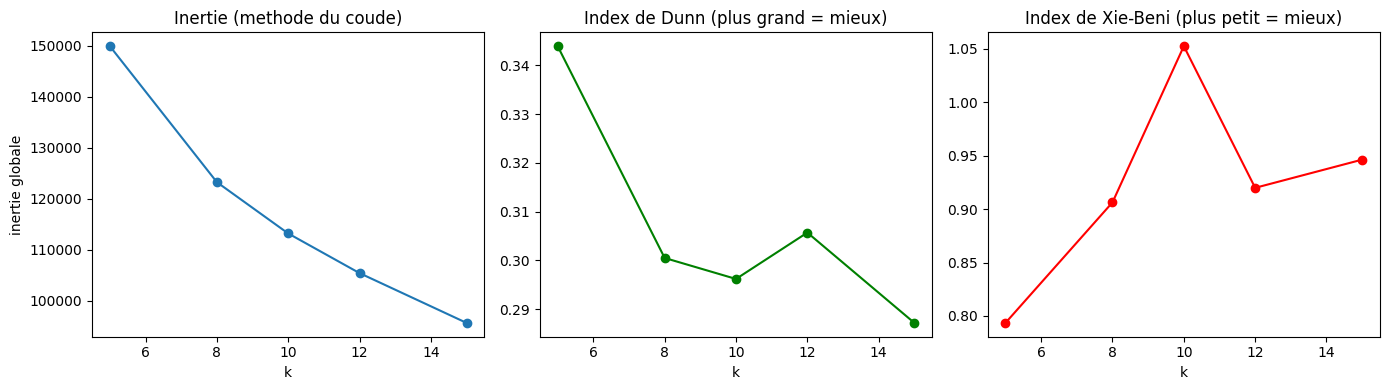

In [ ]:
# Courbes : methode du coude (inertie) et indices de qualite
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(tab_kmeans['k'], tab_kmeans['inertie'], 'o-')
axes[0].set_title("Inertie (methode du coude)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inertie globale")
axes[1].plot(tab_kmeans['k'], tab_kmeans['Dunn'], 'o-', color='green')
axes[1].set_title("Index de Dunn (plus grand = mieux)"); axes[1].set_xlabel("k")
axes[2].plot(tab_kmeans['k'], tab_kmeans['Xie-Beni'], 'o-', color='red')
axes[2].set_title("Index de Xie-Beni (plus petit = mieux)"); axes[2].set_xlabel("k")

plt.tight_layout(); plt.show()

### Analyse des clusters face aux vraies classes (k=5 et k=10)

On compare les partitions du k-means aux dix vraies classes (que le clustering n'a pas vues).
Pour chaque k, on construit la matrice de correspondance clusters x classes, la classe
majoritaire et la pureté de chaque cluster, puis la pureté globale (qui vaut l'accuracy obtenue en
affectant chaque cluster à sa classe majoritaire).

On réutilise les partitions calculées à l'étape A (dictionnaire `partitions`), pour rester
cohérent avec le choix de k.

In [ ]:
# outils d'analyse clusters vs vraies classes
def matrice_clusters_classes(U, y, k):
    # M[cluster, classe] = nombre de points de cette classe dans ce cluster

    M = np.zeros((k, 10), dtype=int)

    for clu, idxs in U.items():
        for i in idxs:
            M[clu, y[i]] += 1

    return M

def analyse_clusters(k):

    U = partitions[k]['U']
    M = matrice_clusters_classes(U, ym, k)
    # heatmap clusters x classes
    plt.figure(figsize=(9, 0.5*k+2))
    plt.imshow(M, cmap='Blues', aspect='auto')
    plt.colorbar()
    plt.xticks(range(10), noms_classes, rotation=45, ha='right')
    plt.yticks(range(k), [f"cluster {j}" for j in range(k)])

    for a in range(k):
        for b in range(10):
            if M[a, b] > 0:
                plt.text(b, a, str(M[a, b]), ha='center', va='center', fontsize=8)

    plt.title(f"Correspondance clusters x vraies classes (k={k})")
    plt.xlabel("vraie classe"); plt.ylabel("cluster")
    plt.tight_layout(); plt.show()

    # classe majoritaire + purete par cluster
    n = len(ym); bien = 0; lignes = []

    for clu in range(k):
        tot = M[clu].sum()
        if tot == 0:
            lignes.append({'cluster':clu, 'taille':0, 'classe_majo':'(vide)', 'purete':0.0}); continue
        cmaj = int(np.argmax(M[clu])); puri = M[clu, cmaj] / tot
        bien += M[clu, cmaj]
        lignes.append({'cluster':clu, 'taille':int(tot), 'classe_majo':noms_classes[cmaj],
                       'purete':round(puri,3)})
        
    tab = pd.DataFrame(lignes)
    purete_globale = bien / n
    
    display(tab)

    print(f"Purete globale (= accuracy cluster -> classe majoritaire) : {purete_globale:.3f}")

    classes_majo = set(l['classe_majo'] for l in lignes if l['classe_majo'] != '(vide)')
    absentes = [noms_classes[c] for c in range(10) if noms_classes[c] not in classes_majo]

    print("Classes qui n'ont aucun cluster propre (jamais majoritaires) :", absentes if absentes else "aucune")

    return M, tab, purete_globale

#### k = 10 : chaque classe a-t-elle son cluster ?

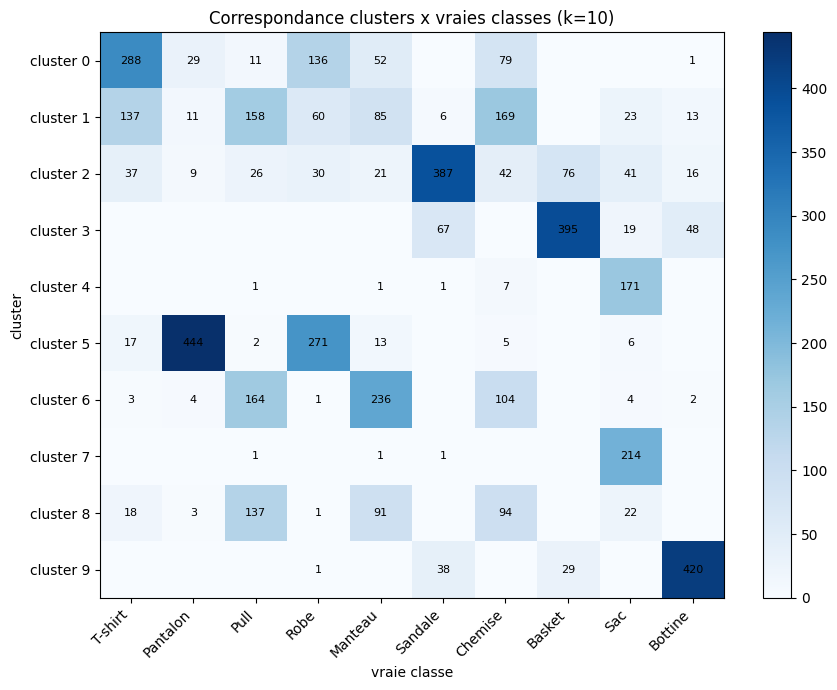

,cluster,taille,classe_majo,purete
0,0,596,T-shirt,0.483
1,1,662,Chemise,0.255
2,2,685,Sandale,0.565
3,3,529,Basket,0.747
4,4,181,Sac,0.945
5,5,758,Pantalon,0.586
6,6,518,Manteau,0.456
7,7,217,Sac,0.986
8,8,366,Pull,0.374
9,9,488,Bottine,0.861


Purete globale (= accuracy cluster -> classe majoritaire) : 0.572
Classes qui n'ont aucun cluster propre (jamais majoritaires) : ['Robe']


In [21]:
M10, tab10, purete10 = analyse_clusters(10)

#### k = 5 : quels groupes sémantiques émergent ?

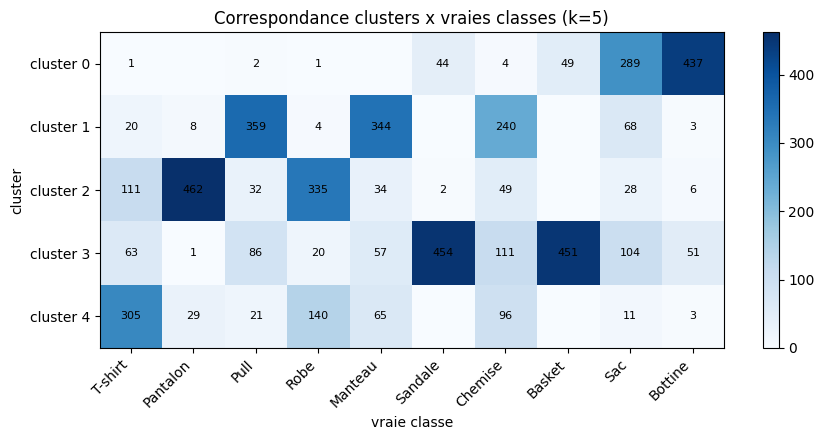

,cluster,taille,classe_majo,purete
0,0,827,Bottine,0.528
1,1,1046,Pull,0.343
2,2,1059,Pantalon,0.436
3,3,1398,Sandale,0.325
4,4,670,T-shirt,0.455


Purete globale (= accuracy cluster -> classe majoritaire) : 0.403
Classes qui n'ont aucun cluster propre (jamais majoritaires) : ['Robe', 'Manteau', 'Chemise', 'Basket', 'Sac']


In [22]:
M5, tab5, purete5 = analyse_clusters(5)

#### Lecture : rapprochement supervisé / non-supervisé

À k=10, on regarde si les « hauts » (T-shirt, Pull, Manteau, Chemise) se répartissent dans des
clusters distincts ou se mélangent. À k=5, on regarde quels grands groupes se forment. On veut voir si le clustering, sans les étiquettes, retrouve la confusion du supervisé.

In [ ]:
# Pour relier au supervise : ou partent les "hauts" et les "chaussures" à k=5 ??

hauts = ['T-shirt','Pull','Manteau','Chemise']
chaussures = ['Sandale','Basket','Bottine']
idx_hauts = [noms_classes.index(c) for c in hauts]
idx_chauss = [noms_classes.index(c) for c in chaussures]

print("k=5 : repartition des HAUTS par cluster (lignes=cluster) :")

for clu in range(5):
    n_hauts = M5[clu, idx_hauts].sum()
    print(f"  cluster {clu} (majo {tab5.loc[clu,'classe_majo']}): {n_hauts} hauts sur {M5[clu].sum()} points")

print("\nk=5 : repartition des CHAUSSURES par cluster :")

for clu in range(5):
    n_ch = M5[clu, idx_chauss].sum()
    print(f"  cluster {clu} (majo {tab5.loc[clu,'classe_majo']}): {n_ch} chaussures sur {M5[clu].sum()} points")

k=5 : repartition des HAUTS par cluster (lignes=cluster) :
  cluster 0 (majo Bottine): 7 hauts sur 827 points
  cluster 1 (majo Pull): 963 hauts sur 1046 points
  cluster 2 (majo Pantalon): 226 hauts sur 1059 points
  cluster 3 (majo Sandale): 317 hauts sur 1398 points
  cluster 4 (majo T-shirt): 487 hauts sur 670 points

k=5 : repartition des CHAUSSURES par cluster :
  cluster 0 (majo Bottine): 530 chaussures sur 827 points
  cluster 1 (majo Pull): 3 chaussures sur 1046 points
  cluster 2 (majo Pantalon): 8 chaussures sur 1059 points
  cluster 3 (majo Sandale): 956 chaussures sur 1398 points
  cluster 4 (majo T-shirt): 3 chaussures sur 670 points


### Clustering hiérarchique (CHA)

Pour compléter le k-means, on applique notre classification hiérarchique ascendante (CHA, code
du TME-09) et on regarde le dendrogramme. L'objectif est seulement visuel : voir quelles classes
fusionnent tôt (donc se ressemblent).

La CHA standard est en O(n^2) avec une matrice de distances mise à jour à chaque fusion. Notre
implémentation, elle, recompute toutes les distances entre groupes à chaque fusion, donc elle est en
O(n^3) : environ 7 minutes pour 300 points, inutilisable sur 5000. On se limite donc à un petit
sous-échantillon équilibré de 30 exemples par classe (300 points), sur la représentation ACP,
graine fixée. C'est suffisant pour un dendrogramme parlant.

In [ ]:
# petit sous-echantillon pour le CHA (O(n^2) en theorie, O(n^3) ici car on recompute tout)

Xc, yc = prepare_multi(data_train, data_test, n_par_classe=30, seed=42)[:2]
Xc_acp, _ = ut.acp(Xc/255.0, 50)
df_cha = pd.DataFrame(Xc_acp)

print("sous-echantillon CHA :", df_cha.shape, "(30/classe)")

# CHA avec linkage complet, distance euclidienne (notre code du TME-09)

link = clust.LinkageComplete()
res_cha = clust.CHA_algorithme(df_cha, link)

print("CHA termine :", len(res_cha), "fusions")

sous-echantillon CHA : (300, 50) (30/classe)


CHA termine : 299 fusions


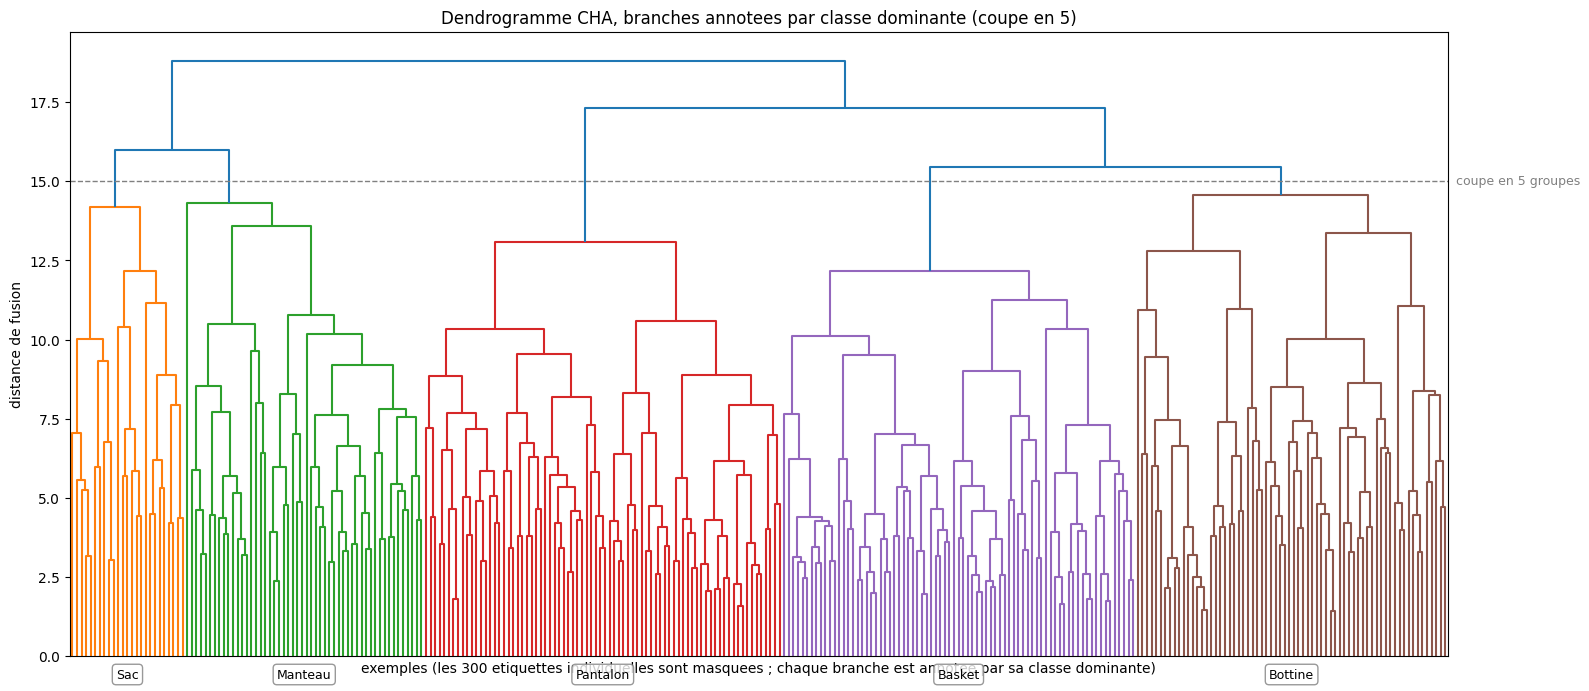

In [ ]:
# Dendrogramme complet, branches annotees par classe dominante (meme calcul, on ne change que l'affichage)
import scipy.cluster.hierarchy as sch

Z = np.array(res_cha, dtype=float)

NB_GROUPES = 5
groupes = sch.fcluster(Z, t=NB_GROUPES, criterion='maxclust')
# seuil de coupe : entre les deux fusions qui encadrent NB_GROUPES groupes
dists = np.sort(Z[:, 2])
seuil = (dists[-NB_GROUPES] + dists[-(NB_GROUPES - 1)]) / 2

dd = sch.dendrogram(Z, no_labels=True, color_threshold=seuil, no_plot=True)
pos_groupe = [groupes[i] for i in dd['leaves']]   # groupe de chaque feuille, de gauche a droite

def classe_dominante(g):

    cnt = np.bincount(yc[groupes == g], minlength=10)
    return noms_classes[int(np.argmax(cnt))]

fig, ax = plt.subplots(figsize=(16, 7))
sch.dendrogram(Z, no_labels=True, color_threshold=seuil, ax=ax)
ax.axhline(y=seuil, color='gray', linestyle='--', linewidth=1)
ax.text(ax.get_xlim()[1], seuil, f"  coupe en {NB_GROUPES} groupes", va='center', fontsize=9, color='gray')

# annoter chaque plage contigue de feuilles d'un meme groupe par sa classe dominante
i, n = 0, len(pos_groupe)

while i < n:
    j = i
    while j < n and pos_groupe[j] == pos_groupe[i]:
        j += 1
    x_centre = 5 + 10 * ((i + j - 1) / 2)
    ax.text(x_centre, -0.02 * Z[:, 2].max(), classe_dominante(pos_groupe[i]),
            ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
    i = j

ax.set_title(f"Dendrogramme CHA, branches annotees par classe dominante (coupe en {NB_GROUPES})")
ax.set_xlabel("exemples (les 300 etiquettes individuelles sont masquees ; chaque branche est annotee par sa classe dominante)")
ax.set_ylabel("distance de fusion")

plt.tight_layout(); plt.show()

Lecture du dendrogramme. La séparation la plus nette est entre vêtements et chaussures : le bloc
de droite regroupe clairement les chaussures (Basket, Bottine, Sandale), bien détaché du reste. Les
quatre « hauts » (T-shirt, Pull, Manteau, Chemise), eux, ne forment pas une branche unique : ils
sont répartis dans plusieurs branches de gauche (dominées par Manteau et Pantalon). Le regroupement
fin des hauts ressort donc mieux en k-means qu'en CHA. C'est attendu : le CHA est notre angle le
plus faible (300 points, linkage complet, plus sensible au bruit). La conclusion d'ensemble ne
change pas, les chaussures restent un groupe net et les vêtements du dessus se mélangent.

In [ ]:
# Coupe du dendrogramme en 5 groupes : composition par classe (pour quantifier la lecture)
groupes = sch.fcluster(Z, t=5, criterion='maxclust')

print("Composition des 5 groupes du dendrogramme (classes dominantes) :")

for g in np.unique(groupes):
    cnt = np.bincount(yc[groupes==g], minlength=10)
    top = np.argsort(cnt)[::-1]
    desc = ", ".join(f"{noms_classes[c]}:{cnt[c]}" for c in top if cnt[c] > 0)
    print(f"  groupe {g} (n={(groupes==g).sum()}): {desc}")

# Part des "hauts" et des "chaussures" dans chaque groupe
hauts = [noms_classes.index(c) for c in ['T-shirt','Pull','Manteau','Chemise']]
chauss = [noms_classes.index(c) for c in ['Sandale','Basket','Bottine']]
print("\nPour chaque groupe : nb de hauts / nb de chaussures / taille")

for g in np.unique(groupes):
    yg = yc[groupes==g]
    nh = sum(np.isin(yg, hauts)); nc = sum(np.isin(yg, chauss))
    
    print(f"  groupe {g}: hauts={nh}, chaussures={nc}, total={len(yg)}")

Composition des 5 groupes du dendrogramme (classes dominantes) :
  groupe 1 (n=25): Sac:15, Chemise:5, Pull:4, T-shirt:1
  groupe 2 (n=52): Manteau:16, T-shirt:13, Pull:12, Chemise:9, Bottine:1, Pantalon:1
  groupe 3 (n=78): Pantalon:29, Robe:28, T-shirt:12, Manteau:5, Chemise:4
  groupe 4 (n=77): Basket:30, Sandale:25, Bottine:6, Chemise:4, T-shirt:4, Sac:2, Manteau:2, Robe:2, Pull:2
  groupe 5 (n=68): Bottine:23, Sac:13, Pull:12, Chemise:8, Manteau:7, Sandale:5

Pour chaque groupe : nb de hauts / nb de chaussures / taille
  groupe 1: hauts=10, chaussures=0, total=25
  groupe 2: hauts=50, chaussures=1, total=52
  groupe 3: hauts=21, chaussures=0, total=78
  groupe 4: hauts=12, chaussures=61, total=77
  groupe 5: hauts=27, chaussures=28, total=68


### Visualisation 2D par ACP

Pour finir, on projette le sous-échantillon sur les 2 premières composantes principales et on
trace deux nuages de points : un coloré par vraie classe, un coloré par cluster k-means. Ça donne
à voir directement quelles classes se chevauchent et lesquelles forment des paquets séparés.

Attention : 2 composantes ne capturent qu'une partie de la variance (environ 47 % ici), donc la
projection écrase beaucoup d'information. On l'interprète avec prudence, comme une illustration
qui complète la matrice de confusion, le k-means et la CHA.

variance expliquee par les 2 composantes : 29.1% + 17.7% = 46.8%


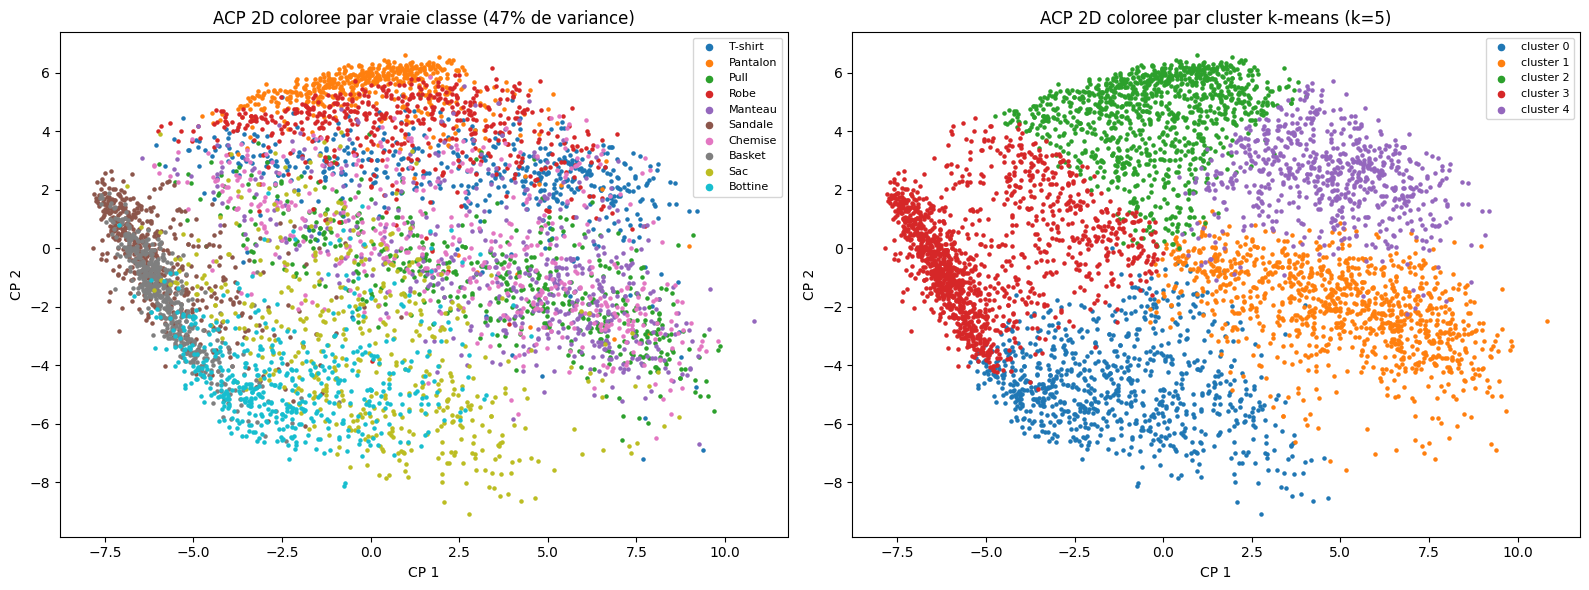

In [ ]:
# projection ACP 2D, colorée par classe puis par cluster
X2, infos2 = ut.acp(Xm/255.0, 2)
var2 = infos2['variance_cumulee'][-1]

print(f"variance expliquee par les 2 composantes : {infos2['variance_expliquee'][0]:.1%} + {infos2['variance_expliquee'][1]:.1%} = {var2:.1%}")

# vecteur d'affectation k-means (k=5, le k prefere par les indices) a partir de la partition de l'etape A
k_viz = 5
lab = np.zeros(len(ym), dtype=int)

for j, idxs in partitions[k_viz]['U'].items():
    for i in idxs:
        lab[i] = j

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) colore par vraie classe
for c in range(10):
    m = ym == c
    axes[0].scatter(X2[m, 0], X2[m, 1], s=5, label=noms_classes[c])
axes[0].legend(markerscale=2, fontsize=8, loc='best')
axes[0].set_title(f"ACP 2D coloree par vraie classe ({var2:.0%} de variance)")
axes[0].set_xlabel("CP 1"); axes[0].set_ylabel("CP 2")

# (2) colore par cluster k-means
for j in range(k_viz):
    m = lab == j
    axes[1].scatter(X2[m, 0], X2[m, 1], s=5, label=f"cluster {j}")

axes[1].legend(markerscale=2, fontsize=8, loc='best')
axes[1].set_title(f"ACP 2D coloree par cluster k-means (k={k_viz})")
axes[1].set_xlabel("CP 1"); axes[1].set_ylabel("CP 2")

plt.tight_layout(); plt.show()